# Metadata formatting

earthkit-plots supports **metadata-aware format strings** in titles, legend labels, and axis labels. Curly-brace placeholders like `{variable_name}` or `{time:%B %Y}` are automatically populated from the data's metadata — regardless of whether it comes from GRIB, netCDF/xarray, or a plain NumPy array.

This notebook covers:
- The `{variable_name}` magic key and how it searches metadata
- How deduplication works when one format string applies to multiple fields
- Time keys: `{time}` (magic), `{time.valid_datetime}`, `{time.step}`, `{time.valid_basetime}` in a multi-panel forecast figure
- Singleton coordinates for point data (`{latitude}`, `{longitude}`)
- Overriding metadata at plot time with `metadata=`

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

### A quick example

Here is what the feature looks like in practice. A single format string is applied to a chart with two layers — temperature and pressure — and all placeholders resolve automatically:

In [ ]:
data = ekd.from_source("sample", "era5-2t-msl-1985122512.grib").to_fieldlist()
temperature, pressure = data

temp_style = ekp.styles.Style(
    levels=range(-20, 21, 2), colors="Spectral_r", units="celsius", extend="both",
)
pressure_style = ekp.styles.Contour(
    levels={"step": 4}, colors="black", units="hPa",
    linewidths=[0.25, 0.25, 0.25, 0.75], labels=True, legend_style=None,
)

chart = ekp.Map(domain="North Atlantic")
chart.contourf(temperature, style=temp_style)
chart.contour(pressure, style=pressure_style)
chart.legend(label="{variable_name} ({units})")
chart.coastlines()
chart.borders()
chart.gridlines()
# {time} resolves to the valid datetime; {variable_name} lists both fields
chart.title("ERA5 {variable_name} – {time:%H:%M UTC on %d %b %Y}")
chart.show()

### `{variable_name}` — a magic key

`{variable_name}` is not a direct attribute lookup. It searches several candidate attributes in priority order and returns the first one it finds:

```
long_name  →  standard_name  →  name  →  short_name
```

The `name` fallback is special: for xarray data it resolves to the `DataArray` name (e.g. `"2t"`), and underscores are replaced with spaces. This makes `{variable_name}` work correctly across GRIB, netCDF, xarray, and NumPy without any extra configuration.

Other magic keys:

| Key | Searches |
|-----|----------|
| `{variable_name}` | `long_name`, `standard_name`, `name`, `short_name` |
| `{ensemble_member}` | `ensemble_member`, `realization`, `number`, `ensemble`, `member` |
| `{location}` | Reverse geocoding from lat/lon (requires `reverse-geocode`) |

### Deduplication — one template, multiple fields

When the same format string is applied across multiple layers or subplots, earthkit-plots collects the resolved value of each key from every field and applies a simple rule:

- **If all fields agree** on a value, it appears once.
- **If fields disagree**, the distinct values are joined into a list — e.g. `"2 metre temperature and Mean sea level pressure"`.

You already saw this in the example above: both layers share the same `{time}`, so it appears once in the title. But `{variable_name}` differs between temperature and pressure, so both names are listed.

This rule applies everywhere a format string is used — chart titles, figure titles, and subplot titles — but **not** to legend labels, where each label is resolved independently for the layer it belongs to.

### Time keys in a multi-panel forecast figure

The deduplication rules and time keys become especially useful in multi-panel forecast figures, where each panel shows a different time step but all panels share the same base time and variable.

The Joachim dataset contains 9 time steps (every 6 hours over two days) of two variables: 10-metre wind gusts (`10fg6`) and mean sea-level pressure (`msl`). Let's look at the fields — notice the column names, which map directly to format keys:

In [3]:
joachim = ekd.from_source(
    "url",
    "https://get.ecmwf.int/repository/test-data/metview/gallery/fc_msl_wg_joachim.grib",
).to_fieldlist()

joachim.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,msl,2011-12-15 00:00:00,2011-12-15,0 days 00:00:00,0,surface,0,regular_ll
1,10fg6,2011-12-15 00:00:00,2011-12-15,0 days 00:00:00,0,surface,0,regular_ll
2,msl,2011-12-15 06:00:00,2011-12-15,0 days 06:00:00,0,surface,0,regular_ll
3,10fg6,2011-12-15 06:00:00,2011-12-15,0 days 06:00:00,0,surface,0,regular_ll
4,msl,2011-12-15 12:00:00,2011-12-15,0 days 12:00:00,0,surface,0,regular_ll
5,10fg6,2011-12-15 12:00:00,2011-12-15,0 days 12:00:00,0,surface,0,regular_ll
6,msl,2011-12-15 18:00:00,2011-12-15,0 days 18:00:00,0,surface,0,regular_ll
7,10fg6,2011-12-15 18:00:00,2011-12-15,0 days 18:00:00,0,surface,0,regular_ll
8,msl,2011-12-16 00:00:00,2011-12-15,1 days 00:00:00,0,surface,0,regular_ll
9,10fg6,2011-12-16 00:00:00,2011-12-15,1 days 00:00:00,0,surface,0,regular_ll


The column names in the `ls()` output hint at the format keys available. Dotted names like `time.valid_datetime` map directly to `{time.valid_datetime}` in a format string — no magic involved, just a direct lookup of that metadata field.

For time, the available keys are:

| Key | What it contains | Varies per panel? |
|-----|-----------------|-------------------|
| `{time}` | **Magic key** — resolves to whichever time best represents *when the data is valid* (valid datetime for forecasts, observation time for analyses) | Yes |
| `{time.valid_datetime}` | The explicit valid (forecast) datetime | Yes |
| `{time.valid_basetime}` | The model run time — when the forecast was initialised | No — same across all panels |
| `{time.step}` | Hours elapsed since the base time | Yes |

`{time}` is a magic key, like `{variable_name}`: it figures out the most appropriate time representation for the data automatically, so you don't need to know whether you have a forecast or an analysis. For most purposes `{time}` and `{time.valid_datetime}` will give the same result, but the explicit dotted form is useful when you want to be precise or when you also need `{time.valid_basetime}` in the same template.

`{parameter.name}` follows the same dotted pattern — a direct lookup of the `parameter.name` metadata field, giving a human-readable variable name for GRIB data.

In the figure below, each panel receives fields at a different valid time, so `{time.valid_datetime}` and `{time.step}` vary per panel and each subplot title is different. `{time.valid_basetime}` is the same across all fields, so it appears just once in the figure title — deduplication at work:

<Figure size 700x700 with 0 Axes>

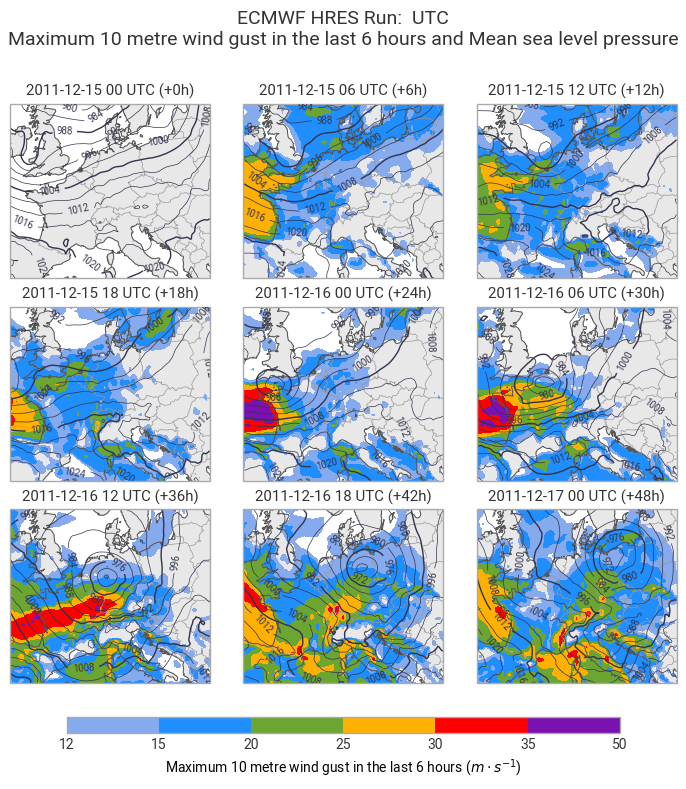

In [9]:
figure = ekp.Figure(domain=[-5, 23, 40, 58], figsize=(7, 7), rows=3, columns=3)

figure.contourf(joachim.sel({"parameter.variable": "10fg6"}), style="auto")
figure.contour(joachim.sel({"parameter.variable": "msl"}), units="hPa", style="auto")

figure.land()
figure.coastlines()
figure.borders()

figure.legend()
figure.subplot_titles("{time.valid_datetime:%Y-%m-%d %H} UTC (+{time.step}h)")
figure.title(
    "ECMWF HRES Run: {time.valid_basetime:%Y-%m-%d %H} UTC\n{parameter.name}",
    y=1.1,
)

figure.show()

### Singleton coordinates — point data

When a coordinate has only a single value (a *scalar coordinate*), earthkit-plots makes it available as a format key named after that coordinate. This is most useful for single-point time series, where `latitude` and `longitude` are scalars.

The `%Lt` and `%Ln` specifiers format them with a degree symbol and N/S or E/W direction:

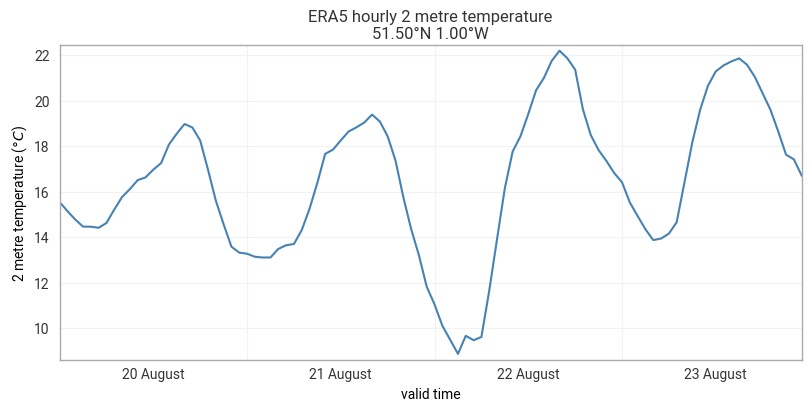

In [5]:
era5_ts = ekd.from_source("sample", "era5-reading-timeseries.nc").to_xarray()

(
    ekp.timeseries
    .line(era5_ts, color="steelblue", units="celsius")
    .title("ERA5 hourly {variable_name}\n{latitude:%Lt} {longitude:%Ln}")
    .xticks(frequency="D", format="%d %B", period=True)
    .show()
)

### Overriding metadata at plot time

Pass `metadata=` to any plotting method to inject or override key/value pairs. This takes precedence over all file-level attributes, making it useful for NumPy arrays (which carry no metadata at all) or to add context not present in the file:

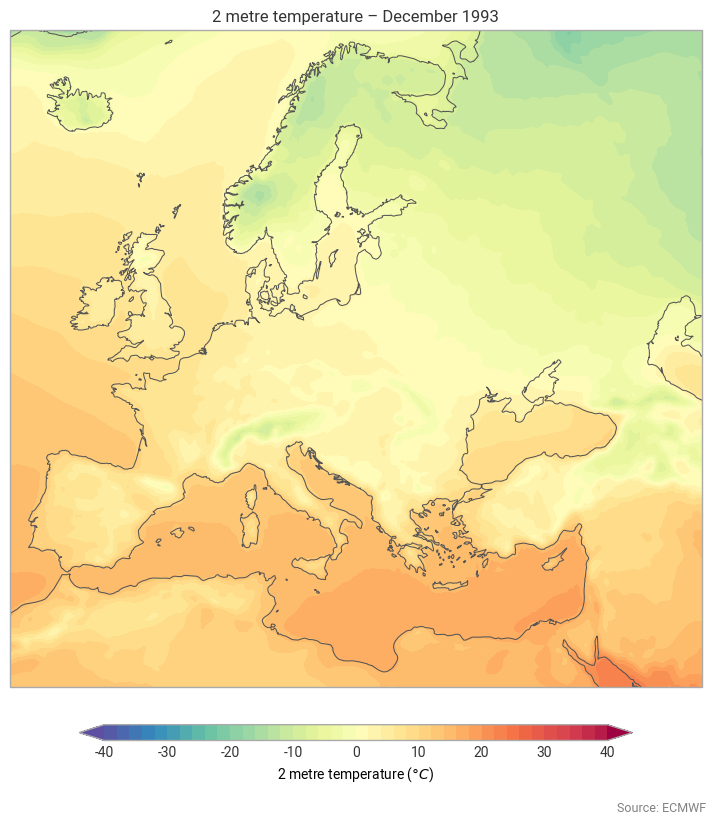

In [6]:
from datetime import datetime

fl = ekd.from_source("sample", "era5-monthly-mean-2t-199312.grib").to_fieldlist()
lats, lons = fl.geography.latlons()
t2m = fl.to_numpy().squeeze()

meta = {
    "units": "K",
    "long_name": "2 metre temperature",
    "time": datetime(1993, 12, 1),
    "institution": "ECMWF",
}

chart = ekp.Map(domain="Europe")
chart.contourf(t2m, x=lons, y=lats, metadata=meta, units="celsius", style="auto")
chart.coastlines()
chart.legend(label="{variable_name} ({units})")
chart.title("{variable_name} – {time:%B %Y}")
chart.attribution("Source: {institution}", location="lower right")
chart.show()

### Quick reference

| Key | What it resolves to |
|-----|---------------------|
| `{variable_name}` | Human-readable variable name — searches `long_name`, `standard_name`, `name`, `short_name` |
| `{parameter.name}` | Direct lookup of the `parameter.name` metadata field (GRIB) |
| `{units}` | Units after any conversion applied at plot time |
| `{time}` | **Magic key** — the time that best represents when the data is valid |
| `{time.valid_datetime:%d %B %Y}` | Explicit valid datetime, formatted with `strftime` codes |
| `{time.valid_basetime}` | Forecast base (run) time |
| `{time.step}` | Forecast lead time in hours |
| `{domain}` | Name of the map domain (named domains only) |
| `{crs}` | Name of the map projection |
| `{latitude:%Lt}` | Latitude with degree symbol and N/S direction |
| `{longitude:%Ln}` | Longitude with degree symbol and E/W direction |
| `{location:%c}` | City name (requires `reverse-geocode`) |
| `{location:%C}` | Country name (requires `reverse-geocode`) |
| `{ensemble_member}` | Ensemble member number |
| `{<any.key>}` | Any dotted metadata key present in the data |

### Exercises

1. Load `era5-monthly-mean-2t-199312.grib` as xarray. Plot it over Europe with a title that includes `{variable_name}` and `{institution}` (the institution is stored as a global attribute on the dataset).

2. Using the Joachim figure above as a starting point, change the subplot titles to show only the lead time (e.g. `+0h`, `+6h`, ...) using `{time.step}`, and update the figure title to include both `{time.valid_basetime}` and `{parameter.name}`.